# Module 3 – Counterfeit Drug Detection

In [ ]:
# Real medicine packaging images (Kaggle) used as genuine class.
# Synthetic counterfeits generated via colour shift, blur, noise, contrast, scratch distortions.
# Dataset capped at 500 per class for efficient training.

## Install Dependencies

In [ ]:
!pip install -q kaggle gradio

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d aryashah2k/mobile-captured-pharmaceutical-medication-packages
!unzip -q mobile-captured-pharmaceutical-medication-packages.zip -d raw_data

for root, dirs, files in os.walk('raw_data'):
    level = root.replace('raw_data', '').count(os.sep)
    if level < 3:
        print(' ' * 2 * level + os.path.basename(root) + '/')
        if level == 2:
            print(' ' * 2*(level+1) + f'({len(files)} images)')

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/mobile-captured-pharmaceutical-medication-packages
License(s): CC-BY-SA-4.0
100% 6.01G/6.01G [00:58<00:00, 111MB/s] 

raw_data/
  Mobile-Captured Pharmaceutical Medication Packages/
    Airoplast nan Tape/
      (26 images)
    Betadine 120 ml mouth wash/
      (26 images)
    Fucidin 20 g cream/
      (26 images)
    Ciprofloxacin Tablets USP 39 10 tablets/
      (26 images)
    Clarinase 14 repetabs/
      (26 images)
    Catafast 9 sachets/
      (26 images)
    Cetal Sinus 20 capsules/
      (26 images)
    Tentavair 160 mcg oral inhalation/
      (26 images)
    C-Retard 10 capsules/
      (26 images)
    Sediproct 20 g cream/
      (26 images)
    Frost 100 ml spray/
      (26 images)
    Congestal 20 tablets/
      (26 images)
    La-vie nan gel/
      (26 images)
    Milga 40 tablets/
      (26 images)
    Gabalepsy 20 capsules/
      (26 images)
    Steronate 20 tablets/
      (26 images)
    Pedical nan syrup/
      (26 

## Imports

In [ ]:
import os, random, numpy as np
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score
)
import seaborn as sns
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
print(f'Device: {DEVICE}')

Device: cuda


## Build Dataset with Synthetic Fakes

Forgery distortions applied (2–3 per image):
- **Colour shift** – channel alteration (cheap ink / wrong printing)
- **Blur region** – Gaussian blur on a patch (smudged logo/text)
- **Noise** – random pixel noise (poor print quality)
- **Low contrast** – faded/washed-out packaging
- **Scratch** – random lines drawn (physical tampering)

In [ ]:
RAW_DIR = Path('raw_data')
real_images = (list(RAW_DIR.rglob('*.jpg')) +
               list(RAW_DIR.rglob('*.jpeg')) +
               list(RAW_DIR.rglob('*.png')))
print(f'Total real images found: {len(real_images)}')

DATASET_DIR = Path('counterfeit_dataset')
for split in ['train','val','test']:
    for cls in ['real','fake']:
        (DATASET_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def make_fake(img):
    img = img.convert('RGB')
    for d in random.sample(['colour_shift','blur_region','noise','low_contrast','scratch'],
                           k=random.randint(2,3)):
        arr = np.array(img).astype(np.float32)
        if d == 'colour_shift':
            ch = random.randint(0,2)
            arr[:,:,ch] = np.clip(arr[:,:,ch]*random.uniform(0.35,0.65), 0, 255)
            img = Image.fromarray(arr.astype(np.uint8))
        elif d == 'blur_region':
            w,h = img.size
            x1,y1 = random.randint(0,w//2), random.randint(0,h//2)
            region = img.crop((x1,y1,x1+w//2,y1+h//2))
            region = region.filter(ImageFilter.GaussianBlur(random.randint(4,9)))
            img.paste(region,(x1,y1))
        elif d == 'noise':
            noise = np.random.normal(0, random.uniform(25,50), arr.shape)
            img   = Image.fromarray(np.clip(arr+noise,0,255).astype(np.uint8))
        elif d == 'low_contrast':
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.15,0.45))
        elif d == 'scratch':
            draw = ImageDraw.Draw(img)
            w,h  = img.size
            for _ in range(random.randint(4,9)):
                c = (random.randint(60,190),)*3
                draw.line([(random.randint(0,w),random.randint(0,h)),
                           (random.randint(0,w),random.randint(0,h))],
                          fill=c, width=random.randint(1,3))
    return img

random.shuffle(real_images)
n = len(real_images)
n_tr = int(0.70*n); n_val = int(0.15*n)
splits = {'train': real_images[:n_tr],
          'val':   real_images[n_tr:n_tr+n_val],
          'test':  real_images[n_tr+n_val:]}

print('Building dataset with synthetic fakes ...')
for split, paths in splits.items():
    for p in paths:
        try:
            img = Image.open(p).convert('RGB')
            img.save(DATASET_DIR / split / 'real' / p.name)
            make_fake(img).save(DATASET_DIR / split / 'fake' / p.name)
        except Exception:
            continue
    r = len(list((DATASET_DIR/split/'real').iterdir()))
    f = len(list((DATASET_DIR/split/'fake').iterdir()))
    print(f'  {split:5s}: {r} real | {f} fake')
print('Done!')

Total real images found: 2850
Building dataset with synthetic fakes ...
  train: 1961 real | 1961 fake
  val  : 426 real | 426 fake
  test : 429 real | 429 fake
Done!


## Visualise Real vs Synthetic Fake Samples

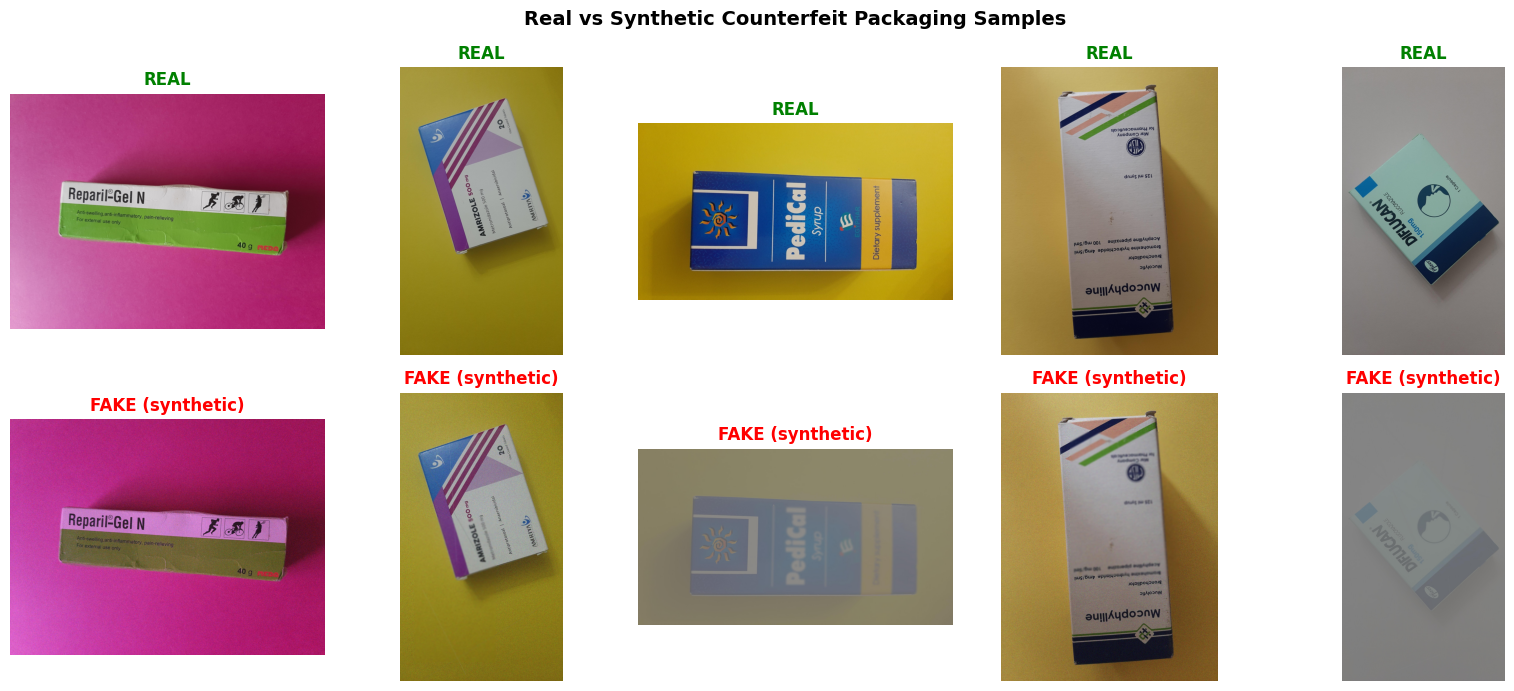

Saved: real_vs_fake_samples.png


In [ ]:
reals = list((DATASET_DIR/'train'/'real').iterdir())[:5]
fakes = list((DATASET_DIR/'train'/'fake').iterdir())[:5]

fig, axes = plt.subplots(2, 5, figsize=(16,7))
for i in range(5):
    axes[0,i].imshow(Image.open(reals[i]))
    axes[0,i].set_title('REAL', color='green', fontweight='bold')
    axes[0,i].axis('off')
    axes[1,i].imshow(Image.open(fakes[i]))
    axes[1,i].set_title('FAKE (synthetic)', color='red', fontweight='bold')
    axes[1,i].axis('off')

plt.suptitle('Real vs Synthetic Counterfeit Packaging Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('real_vs_fake_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: real_vs_fake_samples.png')

## Data Loaders with Dataset Cap
Capped at **500 real + 500 fake per split** for fast training on T4 GPU.

In [ ]:
BATCH = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ── Cap helper ──────────────────────────────────────────────────
def cap_dataset(dataset, max_per_class=500):
    """Randomly select max_per_class images from each class."""
    class_0 = [i for i,(_, lbl) in enumerate(dataset.samples) if lbl == 0]
    class_1 = [i for i,(_, lbl) in enumerate(dataset.samples) if lbl == 1]
    random.shuffle(class_0); random.shuffle(class_1)
    selected = class_0[:max_per_class] + class_1[:max_per_class]
    random.shuffle(selected)
    return Subset(dataset, selected)

# Load full datasets first
train_ds_full = datasets.ImageFolder(DATASET_DIR/'train', transform=train_tf)
val_ds_full   = datasets.ImageFolder(DATASET_DIR/'val',   transform=val_tf)
test_ds_full  = datasets.ImageFolder(DATASET_DIR/'test',  transform=val_tf)

CLASS_NAMES = train_ds_full.classes  # ['fake', 'real']

# Apply cap
train_ds = cap_dataset(train_ds_full, max_per_class=500)  # 1000 total
val_ds   = cap_dataset(val_ds_full,   max_per_class=150)  # 300 total
test_ds  = cap_dataset(test_ds_full,  max_per_class=150)  # 300 total

print(f'Classes : {CLASS_NAMES}')
print(f'Train   : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

train_loader = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Classes : ['fake', 'real']
Train   : 1000 | Val: 300 | Test: 300
Batches — Train: 32 | Val: 10 | Test: 10


## Helper Functions

In [ ]:
MN = np.array([0.485,0.456,0.406])
ST = np.array([0.229,0.224,0.225])
denorm = lambda t: np.clip(t.permute(1,2,0).numpy()*ST+MN, 0, 1)

def train_model(model, epochs=10, lr=1e-4, name='Model'):
    model.to(DEVICE)
    crit  = nn.BCEWithLogitsLoss()
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist  = {'tl':[],'vl':[],'ta':[],'va':[]}
    best_acc, best_wts, no_imp = 0, None, 0

    for ep in range(epochs):
        model.train()
        tl=tc=0
        for x,y in train_loader:
            x,y = x.to(DEVICE), y.float().to(DEVICE)
            opt.zero_grad()
            out = model(x).squeeze(1)
            loss = crit(out,y); loss.backward(); opt.step()
            tl += loss.item()*x.size(0)
            tc += ((out>0).float()==y).sum().item()

        model.eval(); vl=vc=0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(DEVICE), y.float().to(DEVICE)
                out = model(x).squeeze(1)
                loss = crit(out,y)
                vl += loss.item()*x.size(0)
                vc += ((out>0).float()==y).sum().item()

        ta=tc/len(train_ds); va=vc/len(val_ds)
        tl=tl/len(train_ds); vl=vl/len(val_ds)
        hist['tl'].append(tl); hist['vl'].append(vl)
        hist['ta'].append(ta); hist['va'].append(va)
        sched.step()

        if va > best_acc:
            best_acc = va
            best_wts = {k:v.clone() for k,v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        print(f'[{name}] Ep {ep+1:02d}/{epochs} | '
              f'Train L:{tl:.4f} A:{ta:.4f} | Val L:{vl:.4f} A:{va:.4f}')
        if no_imp >= 5:
            print('Early stop.'); break

    model.load_state_dict(best_wts)
    print(f'Best Val Acc: {best_acc:.4f}\n')
    return model, hist


def evaluate(model, loader, name):
    model.eval()
    P,L,PR = [],[],[]
    with torch.no_grad():
        for x,y in loader:
            pr = torch.sigmoid(model(x.to(DEVICE)).squeeze(1)).cpu().numpy()
            PR.extend(pr); P.extend((pr>0.5).astype(int)); L.extend(y.numpy())
    print(f'\n── {name} Test Results ──')
    print(classification_report(L, P, target_names=CLASS_NAMES))
    print(f'ROC-AUC: {roc_auc_score(L,PR):.4f}')
    return L, P, PR


def plot_curves(h, name):
    ep = range(1,len(h['tl'])+1)
    fig,(a1,a2) = plt.subplots(1,2,figsize=(12,4))
    a1.plot(ep,h['tl'],label='Train'); a1.plot(ep,h['vl'],label='Val')
    a1.set_title(f'{name} – Loss'); a1.set_xlabel('Epoch'); a1.legend()
    a2.plot(ep,h['ta'],label='Train'); a2.plot(ep,h['va'],label='Val')
    a2.set_title(f'{name} – Accuracy'); a2.set_xlabel('Epoch'); a2.legend()
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_curves.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'Saved: {name.replace(" ","_")}_curves.png')

def plot_cm(L,P,name):
    cm_ = confusion_matrix(L,P)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_,annot=True,fmt='d',cmap='Blues',
                xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
    plt.title(f'{name} – Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_cm.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'Saved: {name.replace(" ","_")}_cm.png')

def plot_roc(L,PR,name):
    fpr,tpr,_ = roc_curve(L,PR)
    auc = roc_auc_score(L,PR)
    plt.figure(figsize=(5,4))
    plt.plot(fpr,tpr,label=f'AUC={auc:.4f}')
    plt.plot([0,1],[0,1],'--',color='grey')
    plt.title(f'{name} – ROC Curve')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend()
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_roc.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'Saved: {name.replace(" ","_")}_roc.png')

print('Helper functions ready.')

Helper functions ready.


## Model 1: Baseline CNN (from scratch)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32,3,padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64,3,padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256,128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128,1)
        )
    def forward(self,x): return self.classifier(self.features(x))

cnn_model = BaselineCNN()
print(f'Params: {sum(p.numel() for p in cnn_model.parameters()):,}')
cnn_model, cnn_hist = train_model(cnn_model, epochs=10, lr=1e-3, name='Baseline CNN')
torch.save(cnn_model.state_dict(), 'baseline_cnn.pth')
print('Saved: baseline_cnn.pth')

Params: 422,401
[Baseline CNN] Ep 01/10 | Train L:0.5610 A:0.7300 | Val L:0.4100 A:0.8467
[Baseline CNN] Ep 02/10 | Train L:0.4539 A:0.8000 | Val L:0.5060 A:0.7267
[Baseline CNN] Ep 03/10 | Train L:0.4203 A:0.8160 | Val L:0.3374 A:0.8667
[Baseline CNN] Ep 04/10 | Train L:0.3781 A:0.8460 | Val L:0.2927 A:0.8933
[Baseline CNN] Ep 05/10 | Train L:0.3812 A:0.8470 | Val L:0.3700 A:0.8367
[Baseline CNN] Ep 06/10 | Train L:0.3431 A:0.8710 | Val L:0.2698 A:0.9000
[Baseline CNN] Ep 07/10 | Train L:0.3056 A:0.8890 | Val L:0.2999 A:0.8833
[Baseline CNN] Ep 08/10 | Train L:0.3087 A:0.8780 | Val L:0.3338 A:0.8633
[Baseline CNN] Ep 09/10 | Train L:0.3097 A:0.8900 | Val L:0.3039 A:0.8800
[Baseline CNN] Ep 10/10 | Train L:0.2994 A:0.8880 | Val L:0.2968 A:0.8933
Best Val Acc: 0.9000

Saved: baseline_cnn.pth


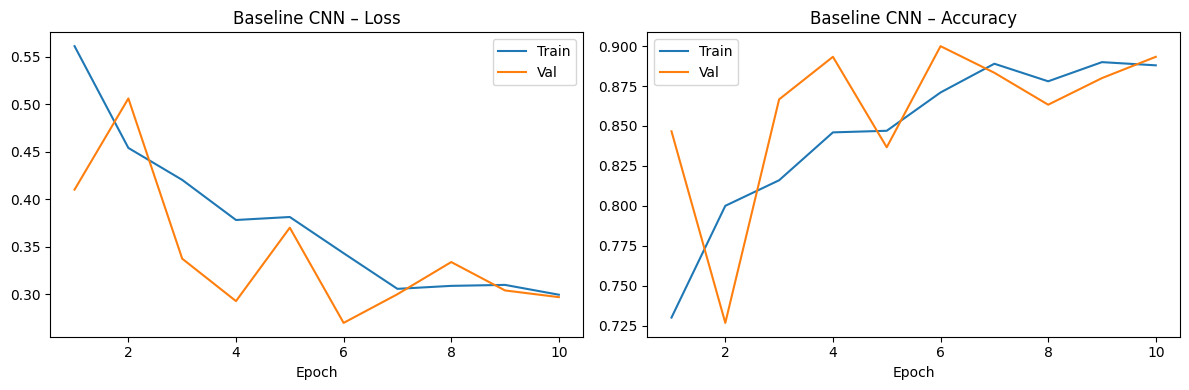

Saved: Baseline_CNN_curves.png

── Baseline CNN Test Results ──
              precision    recall  f1-score   support

        fake       0.92      0.80      0.85       150
        real       0.82      0.93      0.87       150

    accuracy                           0.86       300
   macro avg       0.87      0.86      0.86       300
weighted avg       0.87      0.86      0.86       300

ROC-AUC: 0.9195


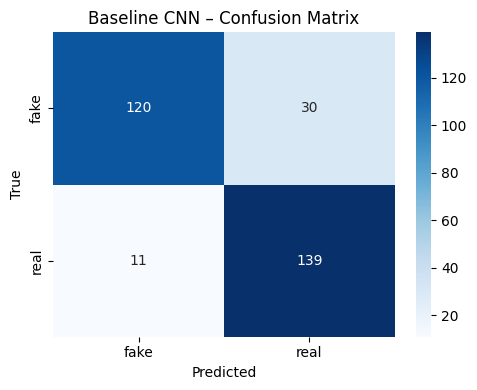

Saved: Baseline_CNN_cm.png


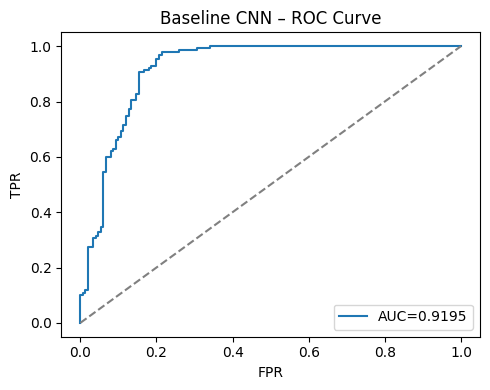

Saved: Baseline_CNN_roc.png


In [ ]:
plot_curves(cnn_hist, 'Baseline CNN')
cnn_L, cnn_P, cnn_PR = evaluate(cnn_model, test_loader, 'Baseline CNN')
plot_cm(cnn_L, cnn_P, 'Baseline CNN')
plot_roc(cnn_L, cnn_PR, 'Baseline CNN')

## Model 2: MobileNetV3-Small (Transfer Learning)

In [ ]:
def build_mobilenet():
    m = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
    in_f = m.classifier[3].in_features
    m.classifier[3] = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f,1))
    return m

mob_model = build_mobilenet()
print(f'Params: {sum(p.numel() for p in mob_model.parameters()):,}')
mob_model, mob_hist = train_model(mob_model, epochs=10, lr=1e-4, name='MobileNetV3')
torch.save(mob_model.state_dict(), 'mobilenet_v3.pth')
print('Saved: mobilenet_v3.pth')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 126MB/s]

Params: 1,518,881


[MobileNetV3] Ep 01/10 | Train L:0.6413 A:0.6220 | Val L:0.6433 A:0.6367
[MobileNetV3] Ep 02/10 | Train L:0.4333 A:0.8510 | Val L:0.4761 A:0.7700
[MobileNetV3] Ep 03/10 | Train L:0.2639 A:0.9150 | Val L:0.4247 A:0.8167
[MobileNetV3] Ep 04/10 | Train L:0.1859 A:0.9340 | Val L:0.3457 A:0.8667
[MobileNetV3] Ep 05/10 | Train L:0.1580 A:0.9450 | Val L:0.3268 A:0.8833
[MobileNetV3] Ep 06/10 | Train L:0.1160 A:0.9620 | Val L:0.2838 A:0.8933
[MobileNetV3] Ep 07/10 | Train L:0.1071 A:0.9590 | Val L:0.2434 A:0.9067
[MobileNetV3] Ep 08/10 | Train L:0.0961 A:0.9700 | Val L:0.2487 A:0.9067
[MobileNetV3] Ep 09/10 | Train L:0.0973 A:0.9680 | Val L:0.2208 A:0.9167
[MobileNetV3] Ep 10/10 | Train L:0.0979 A:0.9730 | Val L:0.2068 A:0.9233
Best Val Acc: 0.9233

Saved: mobilenet_v3.pth


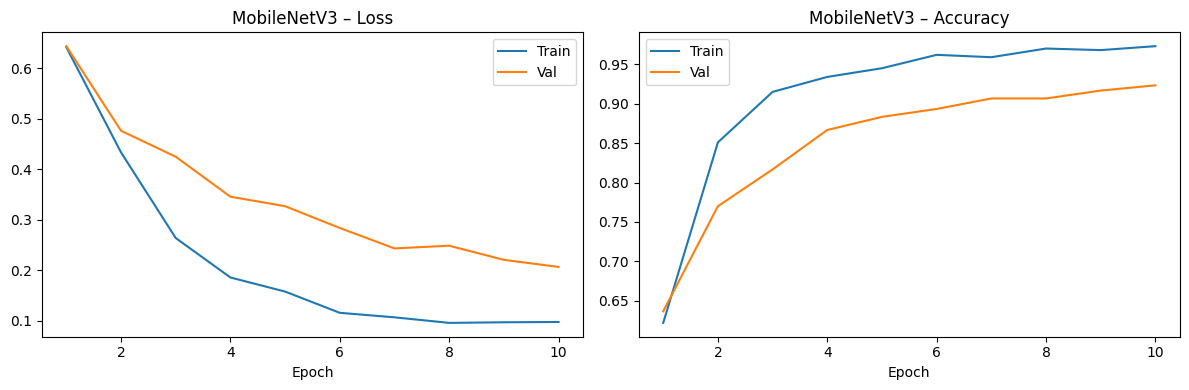

Saved: MobileNetV3_curves.png

── MobileNetV3 Test Results ──
              precision    recall  f1-score   support

        fake       0.99      0.88      0.93       150
        real       0.89      0.99      0.94       150

    accuracy                           0.93       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.94      0.93      0.93       300

ROC-AUC: 0.9956


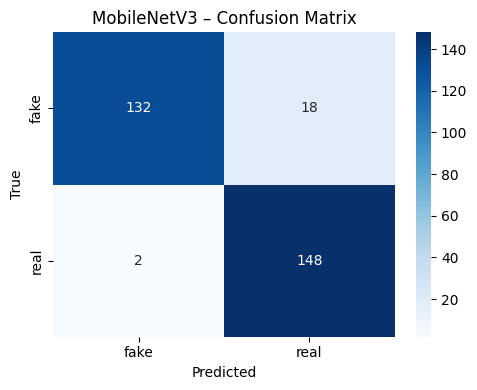

Saved: MobileNetV3_cm.png


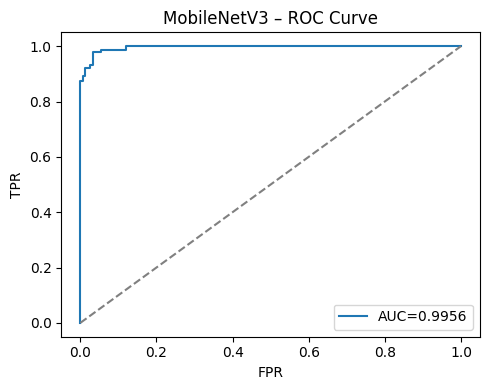

Saved: MobileNetV3_roc.png


In [ ]:
plot_curves(mob_hist, 'MobileNetV3')
mob_L, mob_P, mob_PR = evaluate(mob_model, test_loader, 'MobileNetV3')
plot_cm(mob_L, mob_P, 'MobileNetV3')
plot_roc(mob_L, mob_PR, 'MobileNetV3')

## Model 3: EfficientNet-B0 (Transfer Learning)

In [ ]:
def build_efficientnet():
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    in_f = m.classifier[1].in_features
    m.classifier[1] = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f,1))
    return m

eff_model = build_efficientnet()
print(f'Params: {sum(p.numel() for p in eff_model.parameters()):,}')
eff_model, eff_hist = train_model(eff_model, epochs=10, lr=1e-4, name='EfficientNet-B0')
torch.save(eff_model.state_dict(), 'efficientnet_b0.pth')
print('Saved: efficientnet_b0.pth')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s] 


Params: 4,008,829
[EfficientNet-B0] Ep 01/10 | Train L:0.5931 A:0.7290 | Val L:0.4917 A:0.7967
[EfficientNet-B0] Ep 02/10 | Train L:0.3294 A:0.9130 | Val L:0.2750 A:0.9033
[EfficientNet-B0] Ep 03/10 | Train L:0.1843 A:0.9490 | Val L:0.1870 A:0.9467
[EfficientNet-B0] Ep 04/10 | Train L:0.1265 A:0.9640 | Val L:0.1652 A:0.9567
[EfficientNet-B0] Ep 05/10 | Train L:0.0995 A:0.9690 | Val L:0.1484 A:0.9600
[EfficientNet-B0] Ep 06/10 | Train L:0.0978 A:0.9710 | Val L:0.1089 A:0.9767
[EfficientNet-B0] Ep 07/10 | Train L:0.0959 A:0.9730 | Val L:0.1594 A:0.9567
[EfficientNet-B0] Ep 08/10 | Train L:0.0686 A:0.9810 | Val L:0.1221 A:0.9733
[EfficientNet-B0] Ep 09/10 | Train L:0.0699 A:0.9800 | Val L:0.1236 A:0.9700
[EfficientNet-B0] Ep 10/10 | Train L:0.0593 A:0.9850 | Val L:0.1241 A:0.9700
Best Val Acc: 0.9767

Saved: efficientnet_b0.pth


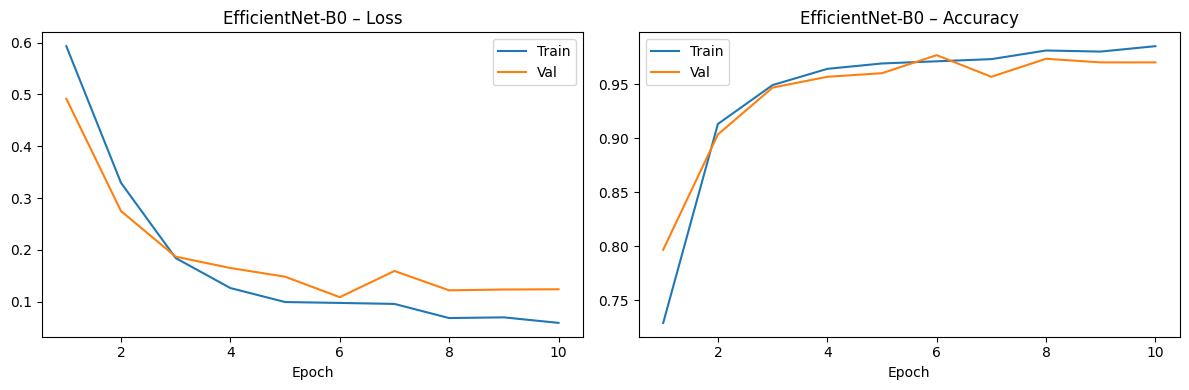

Saved: EfficientNet-B0_curves.png

── EfficientNet-B0 Test Results ──
              precision    recall  f1-score   support

        fake       0.99      0.96      0.97       150
        real       0.96      0.99      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

ROC-AUC: 0.9993


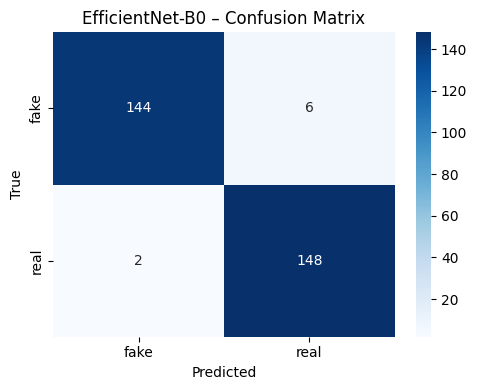

Saved: EfficientNet-B0_cm.png


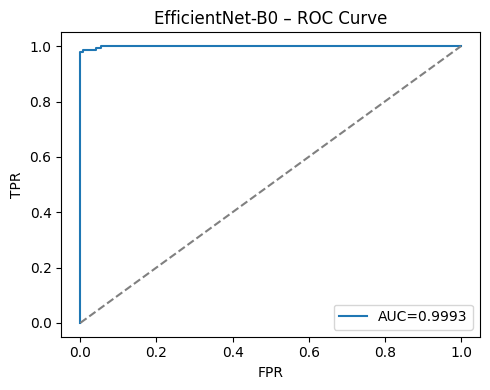

Saved: EfficientNet-B0_roc.png


In [ ]:
plot_curves(eff_hist, 'EfficientNet-B0')
eff_L, eff_P, eff_PR = evaluate(eff_model, test_loader, 'EfficientNet-B0')
plot_cm(eff_L, eff_P, 'EfficientNet-B0')
plot_roc(eff_L, eff_PR, 'EfficientNet-B0')

## Model Comparison Table


── Model Comparison Table ──
                 Accuracy  Precision  Recall  F1 Score  ROC-AUC
Baseline CNN       0.8633     0.8225  0.9267    0.8715   0.9195
MobileNetV3        0.9333     0.8916  0.9867    0.9367   0.9956
EfficientNet-B0    0.9733     0.9610  0.9867    0.9737   0.9993


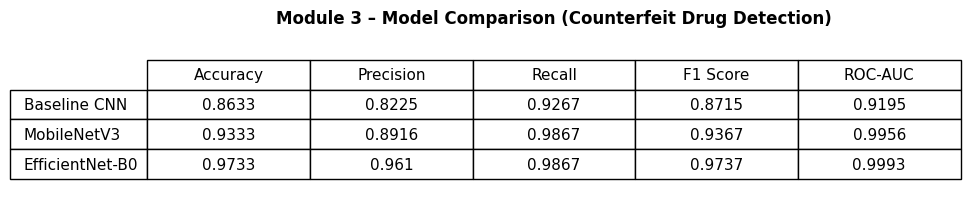

Saved: model_comparison_table.png


In [ ]:
def get_metrics(L,P,PR):
    return {
        'Accuracy' : round(accuracy_score(L,P),4),
        'Precision': round(precision_score(L,P),4),
        'Recall'   : round(recall_score(L,P),4),
        'F1 Score' : round(f1_score(L,P),4),
        'ROC-AUC'  : round(roc_auc_score(L,PR),4),
    }

results = {
    'Baseline CNN'   : get_metrics(cnn_L, cnn_P, cnn_PR),
    'MobileNetV3'    : get_metrics(mob_L, mob_P, mob_PR),
    'EfficientNet-B0': get_metrics(eff_L, eff_P, eff_PR),
}
df = pd.DataFrame(results).T
print('\n── Model Comparison Table ──')
print(df.to_string())

# Save as figure for thesis
fig, ax = plt.subplots(figsize=(10,2.2))
ax.axis('off')
tbl = ax.table(cellText=df.values, rowLabels=df.index,
               colLabels=df.columns, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2,1.9)
plt.title('Module 3 – Model Comparison (Counterfeit Drug Detection)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('model_comparison_table.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: model_comparison_table.png')

## ROC Curve Comparison (All 3 Models)

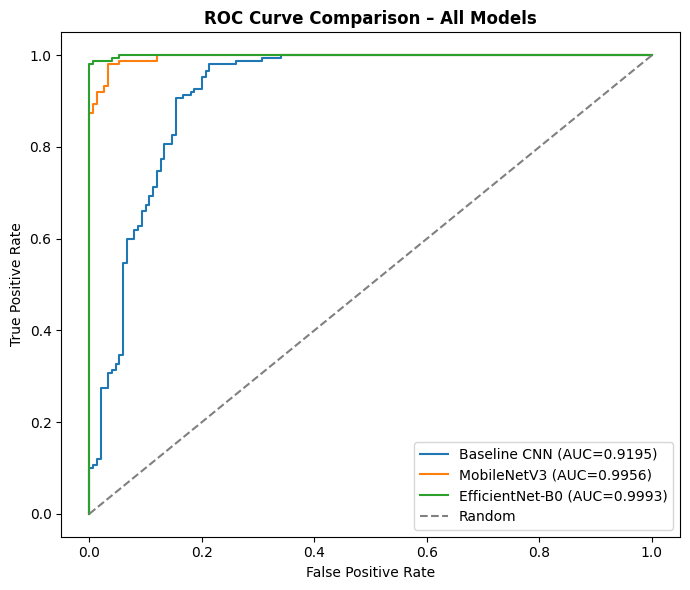

Saved: roc_comparison.png


In [ ]:
plt.figure(figsize=(7,6))
for name,L,PR in [('Baseline CNN',    cnn_L, cnn_PR),
                   ('MobileNetV3',     mob_L, mob_PR),
                   ('EfficientNet-B0', eff_L, eff_PR)]:
    fpr,tpr,_ = roc_curve(L,PR)
    plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(L,PR):.4f})')
plt.plot([0,1],[0,1],'--',color='grey',label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison – All Models', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('roc_comparison.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: roc_comparison.png')

## Grad-CAM Visualisation
Row 1: Original | Row 2: Heatmap | Row 3: Overlay  
Applied to MobileNetV3 and EfficientNet-B0.

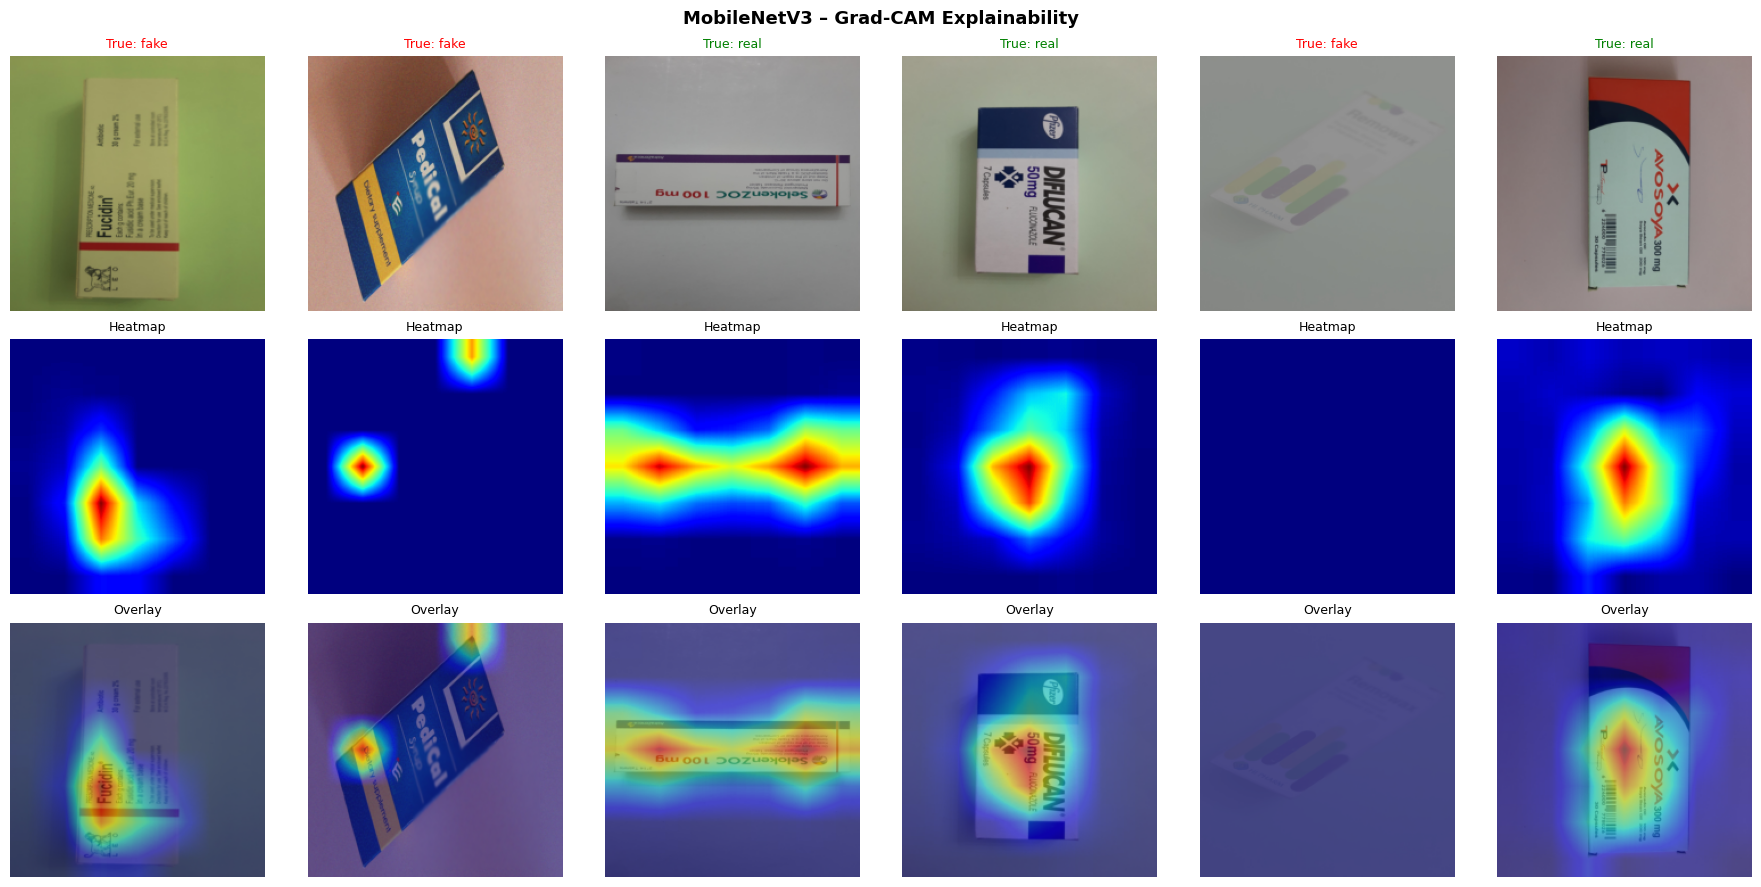

Saved: MobileNetV3_gradcam.png


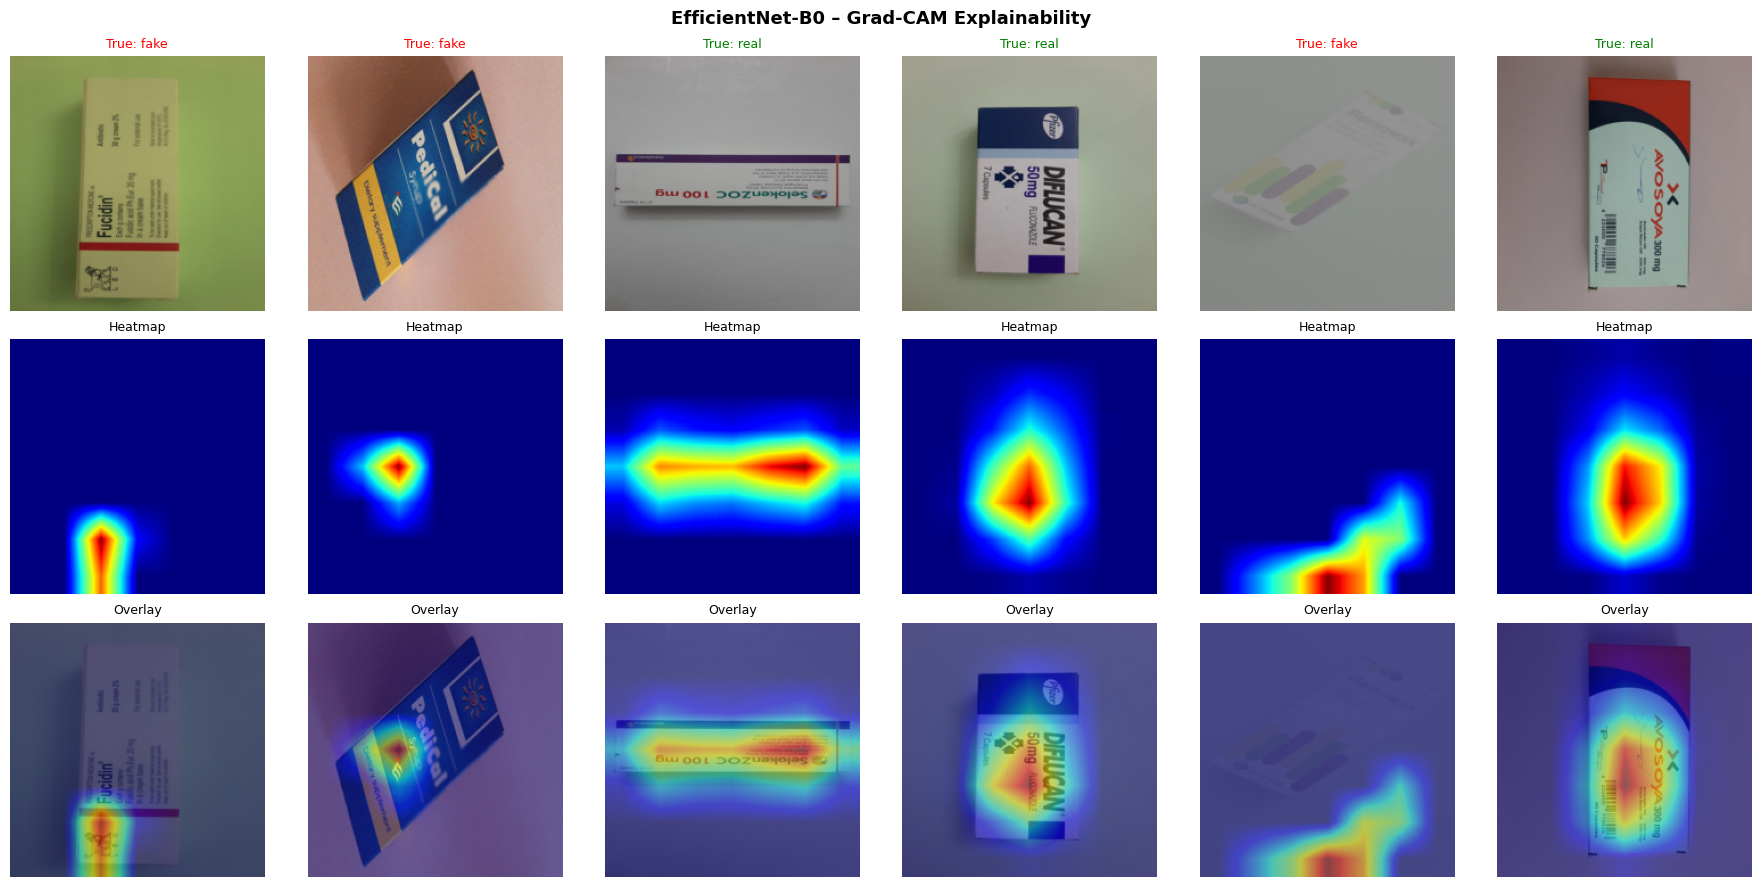

Saved: EfficientNet-B0_gradcam.png


In [ ]:
class GradCAM:
    def __init__(self, model, layer):
        self.model=model; self.grads=None; self.acts=None
        layer.register_forward_hook(
            lambda m,i,o: setattr(self,'acts',o.detach()))
        layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'grads',go[0].detach()))

    def generate(self, img_t):
        self.model.eval()
        out = self.model(img_t.unsqueeze(0).to(DEVICE)).squeeze()
        self.model.zero_grad(); out.backward()
        w   = self.grads.mean(dim=[2,3],keepdim=True)
        cam = torch.clamp((w*self.acts).sum(1).squeeze(), min=0)
        cam = cam/(cam.max()+1e-8)
        return cam.cpu().numpy()


def show_gradcam(model, layer, model_name, n=6):
    gcam = GradCAM(model, layer)
    imgs,lbls = next(iter(test_loader))
    fig, axes = plt.subplots(3, n, figsize=(18,9))
    for i in range(n):
        orig  = denorm(imgs[i])
        label = CLASS_NAMES[lbls[i]]
        color = 'green' if label=='real' else 'red'

        axes[0,i].imshow(orig)
        axes[0,i].set_title(f'True: {label}', color=color, fontsize=9)
        axes[0,i].axis('off')

        cam = gcam.generate(imgs[i])
        cam_up = np.array(
            Image.fromarray((cam*255).astype(np.uint8))
            .resize((IMG_SIZE,IMG_SIZE), Image.BILINEAR)
        ) / 255.0

        axes[1,i].imshow(cm.jet(cam_up)[:,:,:3])
        axes[1,i].set_title('Heatmap', fontsize=9)
        axes[1,i].axis('off')

        overlay = np.clip(0.5*orig + 0.5*cm.jet(cam_up)[:,:,:3], 0, 1)
        axes[2,i].imshow(overlay)
        axes[2,i].set_title('Overlay', fontsize=9)
        axes[2,i].axis('off')

    plt.suptitle(f'{model_name} – Grad-CAM Explainability',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'{model_name.replace(" ","_")}_gradcam.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


show_gradcam(mob_model, mob_model.features[-1], 'MobileNetV3')
show_gradcam(eff_model, eff_model.features[-1], 'EfficientNet-B0')

## Gradio Web Interface
Upload a medicine packaging image → prediction + confidence score + Grad-CAM heatmap.

In [ ]:
import gradio as gr

gcam_ui = GradCAM(eff_model, eff_model.features[-1])

infer_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def predict(image):
    img_pil = image.convert('RGB')
    img_t   = infer_tf(img_pil)

    # Prediction
    eff_model.eval()
    with torch.no_grad():
        logit = eff_model(img_t.unsqueeze(0).to(DEVICE)).squeeze()
    prob_real = torch.sigmoid(logit).item()
    prob_fake = 1 - prob_real

    label = '✅  REAL Medicine Package' if prob_real >= 0.5 else '⚠️  COUNTERFEIT / FAKE Medicine'
    conf  = {'Real': round(prob_real,4), 'Fake': round(prob_fake,4)}

    # Grad-CAM overlay
    cam    = gcam_ui.generate(img_t)
    orig   = np.array(img_pil.resize((IMG_SIZE,IMG_SIZE))) / 255.0
    cam_up = np.array(
        Image.fromarray((cam*255).astype(np.uint8))
        .resize((IMG_SIZE,IMG_SIZE), Image.BILINEAR)
    ) / 255.0
    overlay = Image.fromarray(
        (np.clip(0.5*orig + 0.5*cm.jet(cam_up)[:,:,:3], 0, 1)*255).astype(np.uint8)
    )
    return label, conf, overlay


with gr.Blocks(title='MedGuard AI – Counterfeit Detection') as demo:
    gr.Markdown("""
    # 💊 MedGuard AI – Counterfeit Drug Detection
    **Module 3 | Mohideen Mohamed Rushdi | RGU 2237950 | IIT 20220160**

    Upload a medicine packaging image to detect whether it is **Real or Counterfeit**.
    The Grad-CAM heatmap shows which regions influenced the model's decision.
    """)
    with gr.Row():
        with gr.Column():
            inp = gr.Image(type='pil', label='Upload Medicine Package Image')
            btn = gr.Button('🔍 Analyse', variant='primary')
        with gr.Column():
            out_lbl = gr.Textbox(label='Prediction')
            out_cnf = gr.Label(label='Confidence Scores')
            out_cam = gr.Image(label='Grad-CAM Heatmap (EfficientNet-B0)')
    btn.click(fn=predict, inputs=inp, outputs=[out_lbl, out_cnf, out_cam])
    gr.Markdown("""
    ---
    **Dataset:** Mobile Captured Pharmaceutical Packages (Kaggle) + Synthetic Counterfeits
    **Models Compared:** Baseline CNN | MobileNetV3 | EfficientNet-B0
    **Inference Model:** EfficientNet-B0 (best performing)
    """)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c6357723708815ccc9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
